In [39]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [40]:
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [42]:
import yfinance as yf

@tool
def get_stock_price(symbol: str) -> float:
    """Fetch the latest stock price for a given ticker symbol.

    Args:
        symbol: Stock ticker symbol, e.g. "MSFT", "AAPL", "TSLA".

    Returns:
        The latest traded price as a float.
    """
    ticker = yf.Ticker(symbol)
    price = ticker.fast_info.get("lastPrice")
    if price is None:
        raise ValueError(f"Could not find a price for symbol '{symbol}'")
    return int(price)

tools = [get_stock_price]
llm = init_chat_model("gemini-3.5-flash-lite", model_provider="google_genai")
llm_with_tools = llm.bind_tools(tools)

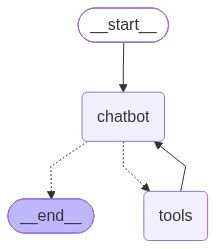

In [43]:
def chatbot(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [46]:
from langsmith import traceable

@traceable
def call_graph(query : str):
    state = graph.invoke({"messages" : [{"role": "user", "content":  query}]})
    return state['messages'][-1].content

call_graph("I want to buy 20 AMZN stocks using current price. then 15 MSFT. what will be the total cost?")
# print(state["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[{'type': 'text',
  'text': 'To calculate the total cost, we multiply the quantity of each stock by its current price:\n\n* **AMZN:** 20 shares × $262.00 = $5,240.00\n* **MSFT:** 15 shares × $495.00 = $7,425.00\n\n**Total Cost:** $5,240.00 + $7,425.00 = **$12,665.00**',
  'extras': {'signature': 'El4KXAERTTIPkOyCtOrIPFF94MF+6zI8SSg1oe8Jjol3zToRO2pe7E0fX8c5LFPvsUqgMhU0SXzgsdP/bW3p9z92f4efWvv2XSpos1zPAlI4maXN82/O6i1mp42VX2lM'}}]

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [45]:
state = graph.invoke({"messages" : [{"role": "user", "content":  "who was Mahatma Gandhi?"}]})
print(state["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[{'type': 'text', 'text': '**Mahatma Gandhi** (born Mohandas Karamchand Gandhi on October 2, 1869 – died January 30, 1948) was an Indian lawyer, anti-colonial nationalist, and political ethicist who led the successful campaign for India\'s independence from British rule. He is internationally revered for his philosophy of **Satyagraha** (truth-force) and **Ahimsa** (absolute non-violence).\n\nHere are the key aspects of his life and legacy:\n\n### 1. Early Life and Legal Career\n* **Birth:** Born into a Hindu merchant-caste family in coastal Gujarat, western India.\n* **Education:** Studied law in London at Inner Temple and was called to the bar at age 22.\n* **South Africa (1893–1914):** Spent 21 years in South Africa, where he first experienced severe racial discrimination against Indians. This injustice galvanized his political activism and led him to develop his foundational ideas of peaceful civil disobedience and resistance.\n\n### 2. Leadership in India’s Independence Movement\n

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
